In [1]:
#used to allow importing of physicsnemo
import sys
sys.path.append("/global/u2/k/kfrields/climsim-kaggle-edition")
from physicsnemo.models.diffusion import *
from baseline_models.unet.training_default.climsim_datasets import *
import numpy as np
from sklearn.metrics import r2_score
import torch
import os, gc
from climsim_utils.data_utils import *
from tqdm import tqdm
from matplotlib import cm
import torch
import statsmodels.api as sm # For QQ plot
from baseline_models.unet.training_default.joint_model import JointModel
from omegaconf import OmegaConf
from torch.utils.data import Dataset, DataLoader
from modulus.distributed import DistributedManager
from torch.utils.data.distributed import DistributedSampler


In [14]:
base_path = '/pscratch/sd/k/kfrields/hugging/E3SM-MMF_saved_models/diffusion_models/rerun_standard_model_pruned_fixed_test/'
config_path = '/pscratch/sd/k/kfrields/hugging/E3SM-MMF_saved_models/diffusion_models/rerun_standard_model_pruned_fixed_test/saved_config.yaml'
with open(config_path, "r") as f:
    cfg=OmegaConf.load(f)
base_path = os.path.join(cfg.save_path, cfg.expname)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

res_std = torch.load(cfg.res_std_path)
res_std = res_std.to(torch.float32)

res_mean = torch.load(cfg.res_mean_path)
res_mean = res_mean.to(torch.float32)

preds_std = torch.load(cfg.preds_std_path)
preds_std = preds_std.to(torch.float32)

preds_mean = torch.load(cfg.preds_mean_path)
preds_mean = preds_mean.to(torch.float32)


grid_info = xr.open_dataset(cfg.grid_info_path)
input_mean = xr.open_dataset(cfg.input_mean_path)
input_max = xr.open_dataset(cfg.input_max_path)
input_min = xr.open_dataset(cfg.input_min_path)
output_scale = xr.open_dataset(cfg.output_scale_path)
qn_lbd = np.loadtxt(cfg.qn_lbd_path, delimiter=',')

data = data_utils(grid_info = grid_info, 
                  input_mean = input_mean, 
                  input_max = input_max, 
                  input_min = input_min, 
                  output_scale = output_scale)

# set variables to subset
if cfg.variable_subsets == 'v1':
    data.set_to_v1_vars()
elif cfg.variable_subsets == 'v1_dyn':
    data.set_to_v1_dyn_vars()
elif cfg.variable_subsets == 'v2':
    data.set_to_v2_vars()
elif cfg.variable_subsets == 'v2_dyn':
    data.set_to_v2_dyn_vars()
elif cfg.variable_subsets == 'v2_rh':
    data.set_to_v2_rh_vars()
elif cfg.variable_subsets == 'v2_rh_mc':
    data.set_to_v2_rh_mc_vars()
elif cfg.variable_subsets == 'v3':
    data.set_to_v3_vars()
elif cfg.variable_subsets == 'v4':
    data.set_to_v4_vars()
else:
    raise ValueError('Unknown variable subset')

input_size = data.input_feature_len
output_size = data.target_feature_len

input_sub, input_div, out_scale = data.save_norm(write=False)



train_dataset = TrainingDataset(parent_path = cfg.data_path,
                                input_sub = input_sub,
                                input_div = input_div,
                                out_scale = out_scale,
                                qinput_prune = cfg.qinput_prune,
                                output_prune = cfg.output_prune,
                                strato_lev = cfg.strato_lev,
                                qn_lbd = qn_lbd,
                                decouple_cloud = cfg.decouple_cloud,
                                aggressive_pruning = cfg.aggressive_pruning,
                                strato_lev_qc = cfg.strato_lev_qc,
                                strato_lev_qinput = cfg.strato_lev_qinput,
                                strato_lev_tinput = cfg.strato_lev_tinput,
                                strato_lev_out = cfg.strato_lev_out,
                                input_clip = cfg.input_clip,
                                input_clip_rhonly = cfg.input_clip_rhonly)


train_loader = DataLoader(train_dataset, 
                                batch_size=cfg.batch_size, 
                                shuffle= True,
                                sampler=None,
                                drop_last=True,
                                #persistent_workers=True,# TEMPORARILY ADDED FOR DEBUGGING
                                #pin_memory=torch.cuda.is_available(),# TEMPORARILY DISABLED FOR DEBUGGING
                                num_workers=cfg.num_workers)

deterministic_model_path = os.path.join(base_path, 'unet_model.pt')
deterministic_model = torch.jit.load(deterministic_model_path).to(device)
deterministic_model.eval()

#Load residual model
diff_path = os.path.join(base_path, 'diff_model.pt')
diff_model = torch.load(diff_path).to(device)
diff_model.eval()
print('here')
joint_model.eval()

joint_model = JointModel(deterministic_model,diff_model, res_std, res_mean, 
                            preds_std, preds_mean, 
                            input_profile_num = data.input_profile_num, 
                            input_scalar_num = data.input_scalar_num,
                            target_profile_num = data.target_profile_num,
                            target_scalar_num = data.target_scalar_num, 
                            condition_channel_num = data.target_profile_num  + data.target_scalar_num + data.input_profile_num + data.input_scalar_num,
                            p_mean = cfg.diffusion_model.p_mean,
                            p_std = cfg.diffusion_model.p_std).to(device)

input paths: ['/pscratch/sd/j/jerrylin/hugging/E3SM-MMF_ne4/preprocessing/v2_rh_mc/train_set/12/train_input.h5', '/pscratch/sd/j/jerrylin/hugging/E3SM-MMF_ne4/preprocessing/v2_rh_mc/train_set/72/train_input.h5', '/pscratch/sd/j/jerrylin/hugging/E3SM-MMF_ne4/preprocessing/v2_rh_mc/train_set/22/train_input.h5', '/pscratch/sd/j/jerrylin/hugging/E3SM-MMF_ne4/preprocessing/v2_rh_mc/train_set/32/train_input.h5', '/pscratch/sd/j/jerrylin/hugging/E3SM-MMF_ne4/preprocessing/v2_rh_mc/train_set/71/train_input.h5', '/pscratch/sd/j/jerrylin/hugging/E3SM-MMF_ne4/preprocessing/v2_rh_mc/train_set/52/train_input.h5', '/pscratch/sd/j/jerrylin/hugging/E3SM-MMF_ne4/preprocessing/v2_rh_mc/train_set/21/train_input.h5', '/pscratch/sd/j/jerrylin/hugging/E3SM-MMF_ne4/preprocessing/v2_rh_mc/train_set/51/train_input.h5', '/pscratch/sd/j/jerrylin/hugging/E3SM-MMF_ne4/preprocessing/v2_rh_mc/train_set/62/train_input.h5', '/pscratch/sd/j/jerrylin/hugging/E3SM-MMF_ne4/preprocessing/v2_rh_mc/train_set/61/train_input.h

In [6]:
train_loop = tqdm(train_loader)

  0%|          | 0/137961 [00:00<?, ?it/s]

In [7]:
train_loop.shape

AttributeError: 'tqdm' object has no attribute 'shape'

In [24]:
with torch.no_grad():
    max_steps = 5
    normalized_res_list = []
    
    joint_model.deterministic_model.eval()
    joint_model.res_model.eval()
    
    current_step = 0
    for data_input, target in train_loop:
        if current_step >= 5:
            break
        data_input, target = data_input.to(device), target.to(device)
    
        #(B, C*L) --> (B, C, L)
        reshape_input = joint_model.reshape_input(data_input)
        target = joint_model.reshape_target(target)
        
        #=====Calculate Residual=====
        #output shape is (B, C, L), scalar values are all expanded mean value across levels
        output = joint_model.deterministic_model(reshape_input)
        
        residual = target - output
        residual = residual.to(output.device)
        
        #======Normalize input and condition data======
        #normalized_residual = residual
        safe_std = torch.clamp(joint_model.res_std, min=1e-2).to(device)
        normalized_residual = ((residual)/((safe_std+ 1e-8)))*.5
        reshaped_normalized_residual = joint_model.reverse_reshape_target(normalized_residual)
        #print(torch.cuda.memory_summary())
        current_step += 1
        normalized_res_list.append(reshaped_normalized_residual.cpu().numpy())
    
    true_res_stack = np.stack(normalized_res_list, axis = 0)

/global/u2/k/kfrields/climsim-kaggle-edition/baseline_models/unet/training_default/climsim_datasets.py:132: RuntimeWarning: divide by zero encountered in divide
  x = (x - self.input_sub) / self.input_div
/global/u2/k/kfrields/climsim-kaggle-edition/baseline_models/unet/training_default/climsim_datasets.py:132: RuntimeWarning: divide by zero encountered in divide
  x = (x - self.input_sub) / self.input_div
/global/u2/k/kfrields/climsim-kaggle-edition/baseline_models/unet/training_default/climsim_datasets.py:132: RuntimeWarning: divide by zero encountered in divide
  x = (x - self.input_sub) / self.input_div
/global/u2/k/kfrields/climsim-kaggle-edition/baseline_models/unet/training_default/climsim_datasets.py:132: RuntimeWarning: divide by zero encountered in divide
  x = (x - self.input_sub) / self.input_div
/global/u2/k/kfrields/climsim-kaggle-edition/baseline_models/unet/training_default/climsim_datasets.py:132: RuntimeWarning: divide by zero encountered in divide
  x = (x - self.inp

In [21]:
normalized_res_stack.reshape(-1, 308).shape

(2560, 308)

In [25]:
true_res_stack_reshaped = true_res_stack.reshape(-1, 308)

true_sample_wise_std = true_res_stack_reshaped.std(axis = 0)
print(true_sample_wise_std.shape)
print(np.median(true_sample_wise_std))


#(B,C*L)->(B,C,L)
true_res_stack = joint_model.reshape_target(torch.tensor(true_res_stack_reshaped))

(308,)
0.50710785


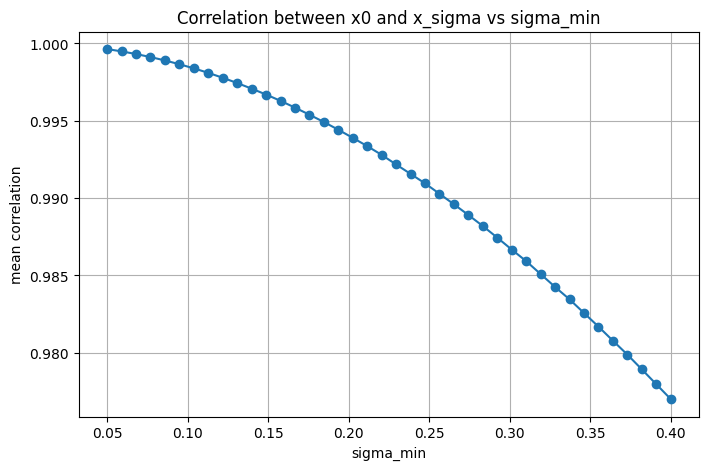

In [29]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# true_res_stack: (B, C, L)
# normalized_res_stack: (B, C, L)
# Make sure these are already on CPU or move them

x0 = true_res_stack  # your normalized true residuals

# Range of sigma_max values to test
sigma_values = torch.linspace(0.05, .4, steps=40)  # adjust upper bound as needed

corr_means = []

for sigma_min in sigma_values:
    # Add noise with fixed sigma_max
    n = torch.randn_like(x0) * sigma_min
    x_sigma = x0 + n

    # Flatten per-sample
    x0_flat = x0.view(x0.size(0), -1)
    xs_flat = x_sigma.view(x_sigma.size(0), -1)

    # Compute correlation per sample
    corrs = []
    for i in range(x0_flat.size(0)):
        c = np.corrcoef(
            x0_flat[i].cpu().numpy(),
            xs_flat[i].cpu().numpy()
        )[0, 1]
        corrs.append(c)

    corr_means.append(np.mean(corrs))

# Convert to numpy for plotting
sigma_values_np = sigma_values.cpu().numpy()
corr_means_np = np.array(corr_means)

# Plot
plt.figure(figsize=(8,5))
plt.plot(sigma_values_np, corr_means_np, marker='o')
plt.xlabel("sigma_min")
plt.ylabel("mean correlation")
plt.title("Correlation between x0 and x_sigma vs sigma_min")
plt.grid(True)
plt.show()


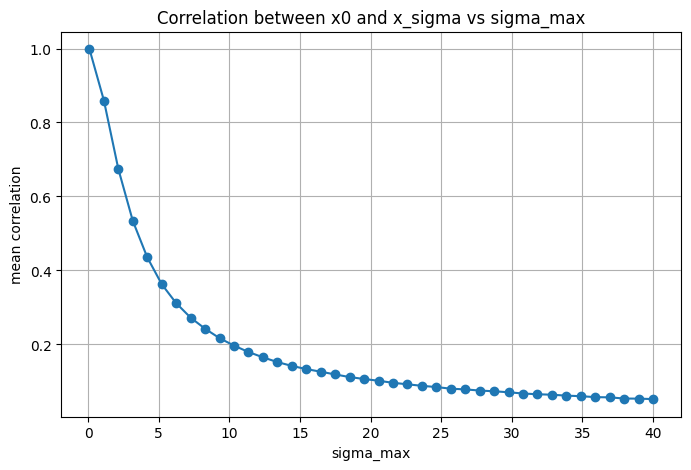

In [30]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# true_res_stack: (B, C, L)
# normalized_res_stack: (B, C, L)
# Make sure these are already on CPU or move them

x0 = true_res_stack  # your normalized true residuals

# Range of sigma_max values to test
sigma_values = torch.linspace(0.1, 40, steps=40)  # adjust upper bound as needed

corr_means = []

for sigma_max in sigma_values:
    # Add noise with fixed sigma_max
    n = torch.randn_like(x0) * sigma_max
    x_sigma = x0 + n

    # Flatten per-sample
    x0_flat = x0.view(x0.size(0), -1)
    xs_flat = x_sigma.view(x_sigma.size(0), -1)

    # Compute correlation per sample
    corrs = []
    for i in range(x0_flat.size(0)):
        c = np.corrcoef(
            x0_flat[i].cpu().numpy(),
            xs_flat[i].cpu().numpy()
        )[0, 1]
        corrs.append(c)

    corr_means.append(np.mean(corrs))

# Convert to numpy for plotting
sigma_values_np = sigma_values.cpu().numpy()
corr_means_np = np.array(corr_means)

# Plot
plt.figure(figsize=(8,5))
plt.plot(sigma_values_np, corr_means_np, marker='o')
plt.xlabel("sigma_max")
plt.ylabel("mean correlation")
plt.title("Correlation between x0 and x_sigma vs sigma_max")
plt.grid(True)
plt.show()
